# 06 — Análisis Integrado de Resultados

Análisis avanzado sobre los resultados de sentimiento (03) y postura (05).

| Sección | Contenido |
|---|---|
| 1 | Detección de shocks de sentimiento |
| 2 | Sentimiento por entidad nombrada (NER) |
| 3 | Multipartidismo España 2023 |
| 4 | Comparativa GPT-4o mini |
| 5 | Correlación sentimiento × resultado electoral |
| 6 | Conclusiones integradas |

**Prerequisito**: haber ejecutado `03_sentiment_scraped.ipynb` y `05_stance_scraped.ipynb`.

In [1]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', '-q',
        'google-cloud-storage', 'pyarrow', 'matplotlib', 'seaborn',
        'scipy', 'spacy', 'openai'], check=True)
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm', '-q'], check=True)
    subprocess.run(['python', '-m', 'spacy', 'download', 'es_core_news_sm', '-q'], check=True)
    SA = '/content/service-account.json'
    assert os.path.exists(SA), 'Sube service-account.json a /content/'
else:
    SA = '/Users/jimenamillamoreno/Desktop/TFM/TFM/scrapper/service-account.json'

print('Setup OK')

Setup OK


In [2]:
import io, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind
from google.cloud import storage
from google.oauth2 import service_account

os.makedirs('figures', exist_ok=True)

_creds = service_account.Credentials.from_service_account_file(SA)
_gcli  = storage.Client(credentials=_creds)

CURATED_BUCKET = 'tfm-twitter-curated'
CAMPAIGNS      = ['brexit_2016', 'trump_2016', 'trump_2024', 'españa_2023']
COLORS         = {'negativo': '#e74c3c', 'neutro': '#95a5a6', 'positivo': '#2ecc71'}

KEY_EVENTS = {
    'brexit_2016': [
        ('2016-05-16', 'Informe HM Treasury\n(impacto económico Brexit)'),
        ('2016-06-16', 'Asesinato Jo Cox'),
        ('2016-06-23', 'Día del referéndum'),
        ('2016-06-24', 'Resultado: Leave gana\nDimisión Cameron'),
    ],
    'trump_2016': [
        ('2016-09-26', '1er debate\nTrump-Clinton'),
        ('2016-10-07', 'Grabación\n"Access Hollywood"'),
        ('2016-10-09', '2o debate'),
        ('2016-10-28', 'Carta Comey/FBI\n(emails Hillary)'),
        ('2016-11-08', 'Día de elecciones'),
        ('2016-11-09', 'Trump gana'),
    ],
    'trump_2024': [
        ('2024-09-10', 'Debate Trump-Harris'),
        ('2024-09-15', '2o intento asesinato\n(Ryan Routh)'),
        ('2024-10-01', 'Debate VP\nWalz vs Vance'),
        ('2024-10-05', 'Huracán Milton'),
        ('2024-11-05', 'Día de elecciones'),
        ('2024-11-06', 'Trump gana'),
    ],
    'españa_2023': [
        ('2023-07-07', 'Inicio oficial campaña\n(Chupinazo San Fermín)'),
        ('2023-07-10', 'Debate Feijóo-Sánchez\nAtresMedia'),
        ('2023-07-21', 'Fin de campaña electoral'),
        ('2023-07-22', 'Jornada de reflexión'),
        ('2023-07-23', 'Elecciones 23J'),
        ('2023-07-24', 'PP gana sin mayoría\nBloqueo gobierno'),
    ],
}

print('Imports OK')

Imports OK


In [3]:
# Cargar resultados de sentimiento (E0) para todas las campañas
dfs = {}
for campaign in CAMPAIGNS:
    buf = io.BytesIO(_gcli.bucket(CURATED_BUCKET).blob(f'results/sentiment_scraped/{campaign}.parquet').download_as_bytes())
    df  = pd.read_parquet(buf)
    df['date']       = pd.to_datetime(df['date'])
    df['created_at'] = pd.to_datetime(df['created_at'], utc=True)
    dfs[campaign]    = df
    print(f'{campaign}: {len(df):,} tweets | cols={list(df.columns)}')

# España dual (E0 + RoBERTuito)
buf_es = io.BytesIO(_gcli.bucket(CURATED_BUCKET).blob('results/sentiment_scraped/españa_2023_dual.parquet').download_as_bytes())
df_es_dual = pd.read_parquet(buf_es)
df_es_dual['date'] = pd.to_datetime(df_es_dual['date'])
print(f'\nEspaña dual: {len(df_es_dual):,} tweets')
print('Carga OK')

brexit_2016: 15,046 tweets | cols=['id', 'text', 'text_clean', 'created_at', 'date', 'campaign', 'like_count', 'retweet_count', 'reply_count', 'sentiment', 'sentiment_score', 'polarity']
trump_2016: 27,776 tweets | cols=['id', 'text', 'text_clean', 'created_at', 'date', 'campaign', 'like_count', 'retweet_count', 'reply_count', 'sentiment', 'sentiment_score', 'polarity']
trump_2024: 33,957 tweets | cols=['id', 'text', 'text_clean', 'created_at', 'date', 'campaign', 'like_count', 'retweet_count', 'reply_count', 'sentiment', 'sentiment_score', 'polarity']
españa_2023: 36,383 tweets | cols=['id', 'text', 'text_clean', 'created_at', 'date', 'campaign', 'like_count', 'retweet_count', 'reply_count', 'sentiment', 'sentiment_score', 'polarity']

España dual: 36,383 tweets
Carga OK


## 1. Detección de shocks de sentimiento

Identificamos días con variaciones estadísticamente anómalas en la polaridad media (z-score > 2σ respecto a la media de la campaña). Los shocks positivos y negativos se anotan con los eventos clave para evaluar su correspondencia.

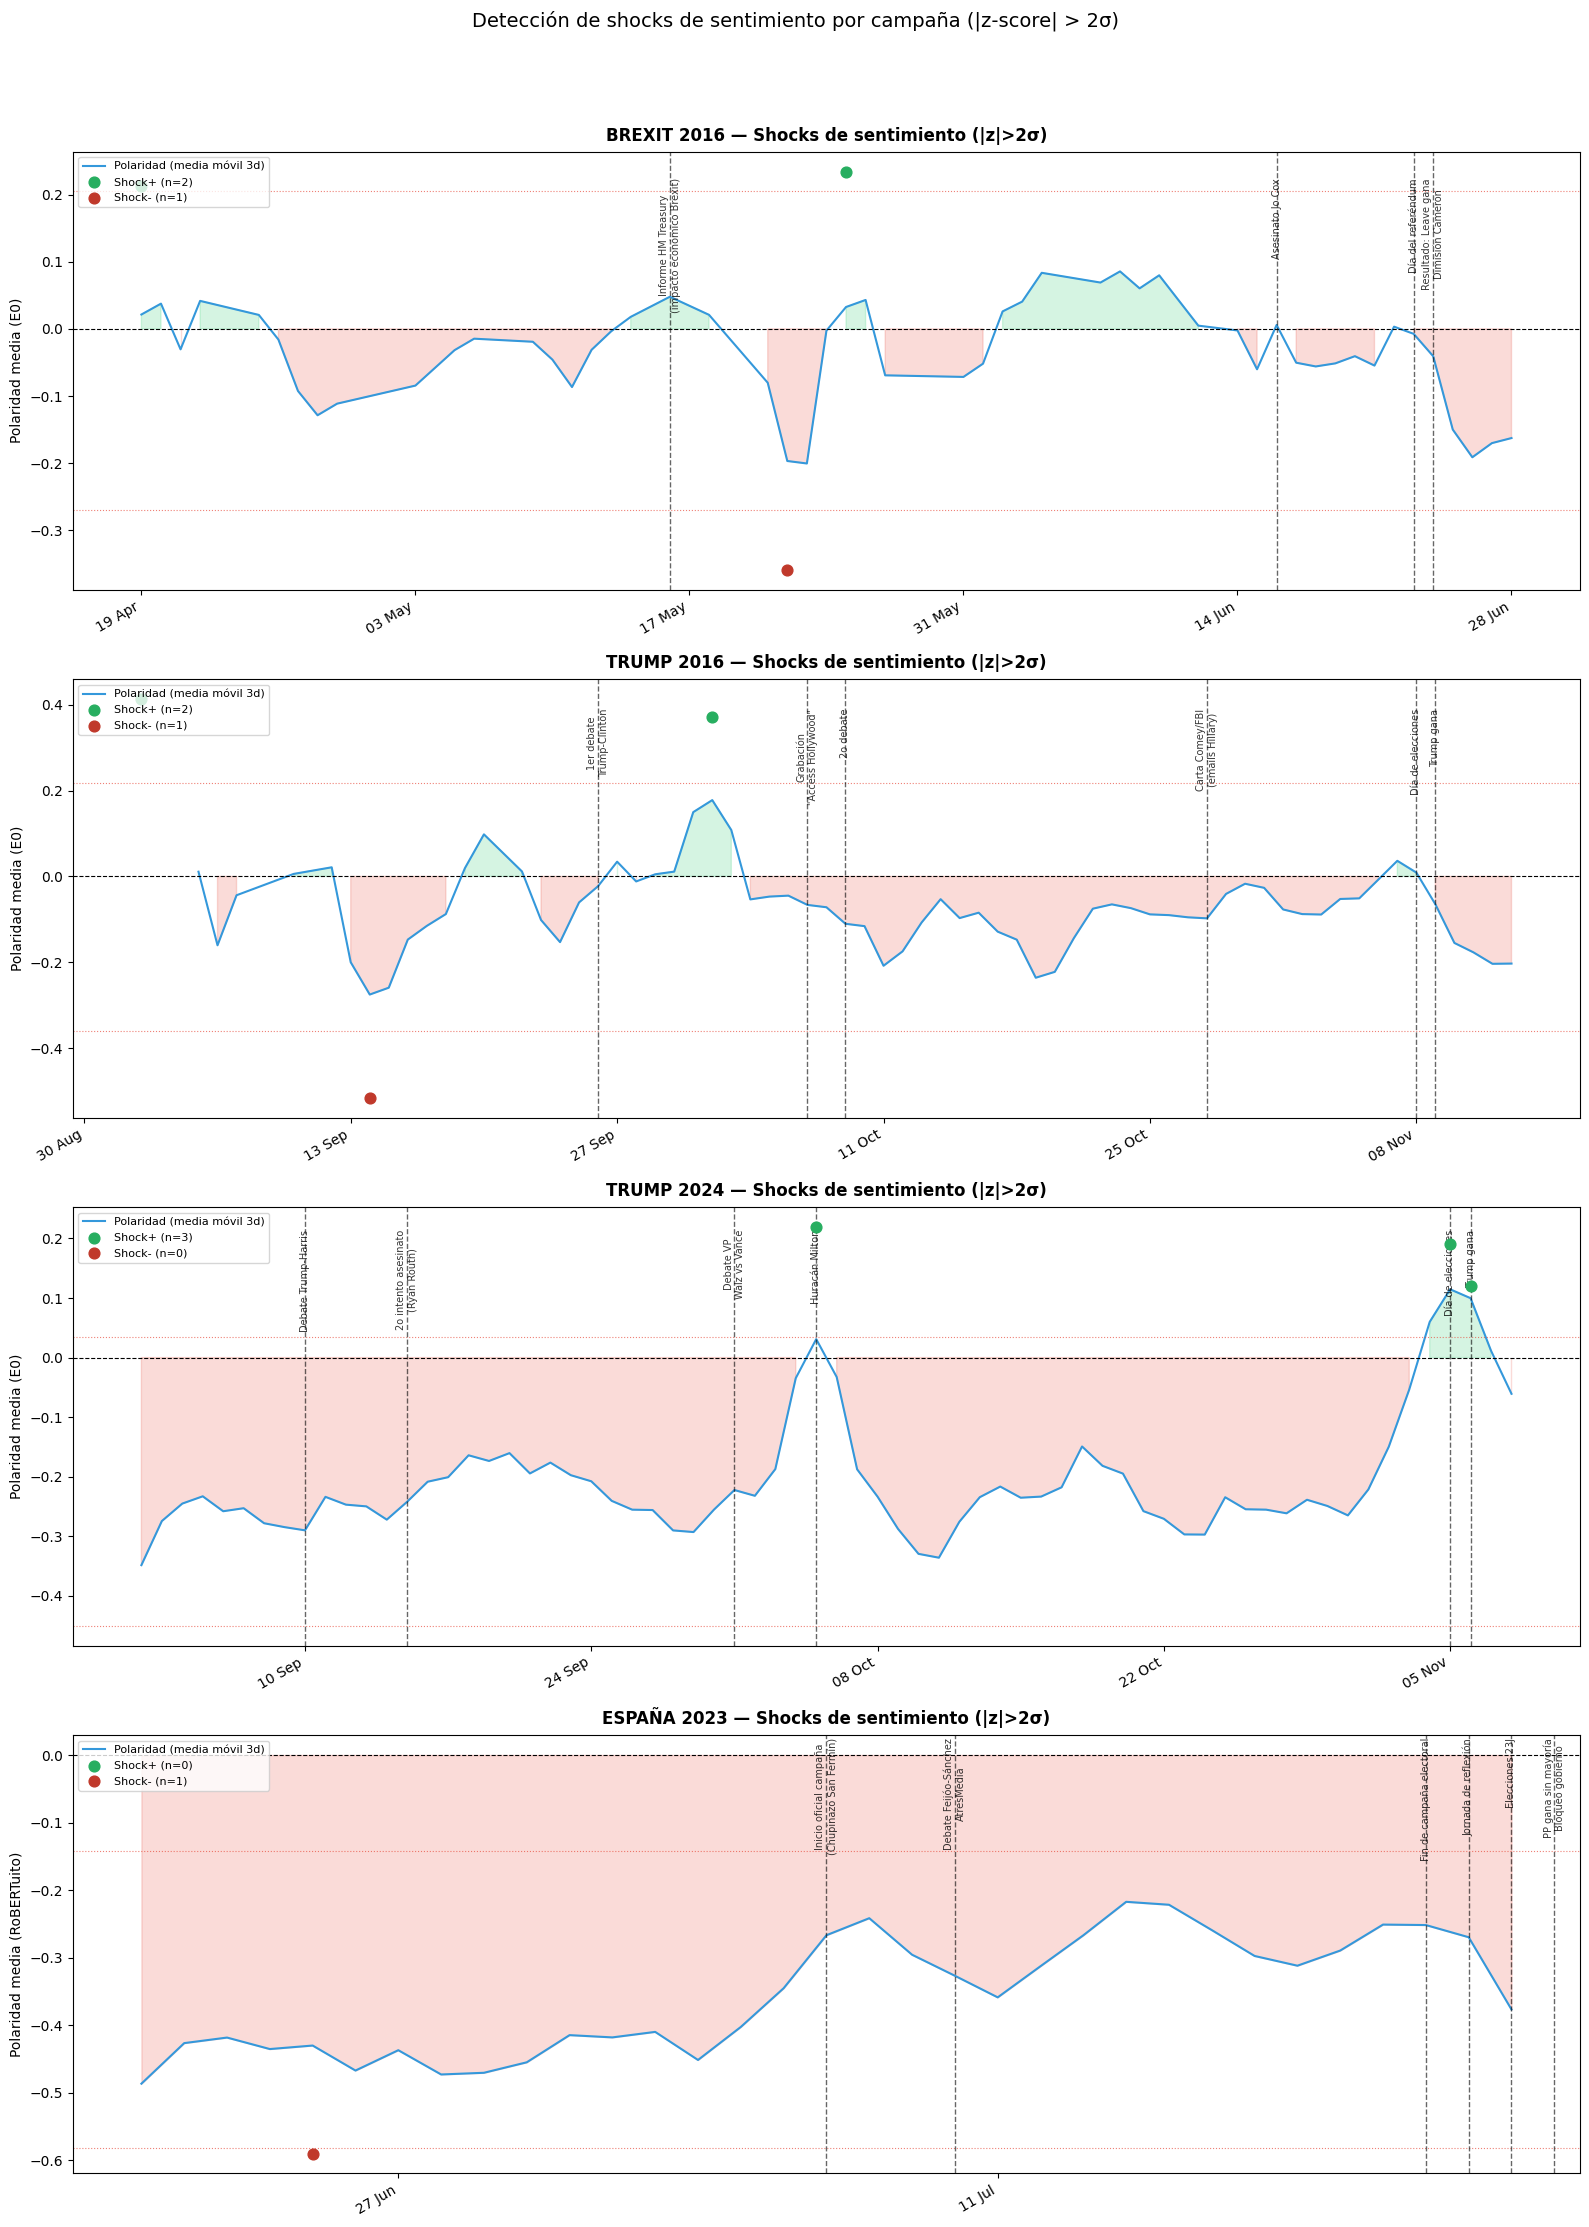


Shocks detectados:
      campaign        date     z     pol     n
0  brexit_2016  2016-04-19  2.07  0.2133    23
1  brexit_2016  2016-05-22 -2.76 -0.3590    11
2  brexit_2016  2016-05-25  2.25  0.2343    64
3   trump_2016  2016-09-02  3.35  0.4127    11
4   trump_2016  2016-09-14 -3.07 -0.5162    52
5   trump_2016  2016-10-02  3.06  0.3707    20
6   trump_2024  2024-10-05  3.52  0.2190   137
7   trump_2024  2024-11-05  3.29  0.1916  4744
8   trump_2024  2024-11-06  2.70  0.1202  5485
9  españa_2023  2023-06-25 -2.07 -0.5900    84


In [4]:
fig, axes = plt.subplots(4, 1, figsize=(16, 22))

shock_summary = []

for ax, (campaign, df) in zip(axes, dfs.items()):
    # Usar RoBERTuito para España
    if campaign == 'españa_2023':
        pol_col = 'polarity_robertuito'
        df_plot = df_es_dual.copy()
    else:
        pol_col = 'polarity'
        df_plot = df.copy()

    daily = df_plot.groupby('date').agg(
        pol_mean=(pol_col, 'mean'),
        n=(pol_col, 'count'),
    ).reset_index()
    daily['date'] = pd.to_datetime(daily['date'])
    daily = daily[daily['n'] >= 10]  # mínimo 10 tweets/día

    # Z-score de polaridad
    mu  = daily['pol_mean'].mean()
    sig = daily['pol_mean'].std()
    daily['z'] = (daily['pol_mean'] - mu) / sig
    daily['rolling_pol'] = daily['pol_mean'].rolling(3, center=True).mean()

    # Shocks: |z| > 2
    shocks_pos = daily[daily['z'] >  2]
    shocks_neg = daily[daily['z'] < -2]

    ax.plot(daily['date'], daily['rolling_pol'], color='#3498db', lw=1.5, label='Polaridad (media móvil 3d)')
    ax.fill_between(daily['date'], daily['rolling_pol'], 0, where=daily['rolling_pol'] > 0,
                    alpha=0.2, color='#2ecc71')
    ax.fill_between(daily['date'], daily['rolling_pol'], 0, where=daily['rolling_pol'] < 0,
                    alpha=0.2, color='#e74c3c')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.axhline(mu + 2*sig, color='#e74c3c', lw=0.8, ls=':', alpha=0.7)
    ax.axhline(mu - 2*sig, color='#e74c3c', lw=0.8, ls=':', alpha=0.7)

    # Marcar shocks
    ax.scatter(shocks_pos['date'], shocks_pos['pol_mean'], color='#27ae60', zorder=5, s=60, label=f'Shock+ (n={len(shocks_pos)})')
    ax.scatter(shocks_neg['date'], shocks_neg['pol_mean'], color='#c0392b', zorder=5, s=60, label=f'Shock- (n={len(shocks_neg)})')

    # Eventos
    for event_date, label in KEY_EVENTS.get(campaign, []):
        ed = pd.Timestamp(event_date)
        if daily['date'].min() <= ed <= daily['date'].max():
            ax.axvline(ed, color='black', linestyle='--', lw=1, alpha=0.6)
            ymin, ymax = ax.get_ylim()
            ax.text(ed, ymax * 0.85, label, fontsize=7, ha='center', va='top',
                    rotation=90, color='black', alpha=0.8)

    ax.set_ylabel('Polaridad media' + (' (RoBERTuito)' if campaign == 'españa_2023' else ' (E0)'))
    ax.set_title(f'{campaign.replace("_"," ").upper()} — Shocks de sentimiento (|z|>2σ)', fontsize=12, fontweight='bold', pad=8)
    ax.legend(loc='upper left', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    # Registrar shocks
    for _, row in pd.concat([shocks_pos, shocks_neg]).sort_values('date').iterrows():
        shock_summary.append({'campaign': campaign, 'date': row['date'].date(),
                               'z': round(row['z'], 2), 'pol': round(row['pol_mean'], 4), 'n': int(row['n'])})

plt.suptitle('Detección de shocks de sentimiento por campaña (|z-score| > 2σ)', fontsize=14, y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('figures/06_sentiment_shocks.png', dpi=150, bbox_inches='tight')
plt.show()

df_shocks = pd.DataFrame(shock_summary)
print('\nShocks detectados:')
print(df_shocks.to_string())

## 2. Sentimiento por entidad nombrada (NER)

Usamos spaCy para extraer personas y organizaciones mencionadas en los tweets. Para cada entidad con suficiente frecuencia, calculamos el sentimiento medio de los tweets que la contienen.

In [5]:
import spacy

# Cargar modelos NER
nlp_en = spacy.load('en_core_web_sm', disable=['parser', 'lemmatizer'])
nlp_es = spacy.load('es_core_news_sm', disable=['parser', 'lemmatizer'])

def extract_entities(texts, nlp, batch_size=512):
    """Extrae PERSON y ORG de una lista de textos."""
    entities = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        ents = list({ent.text.strip() for ent in doc.ents if ent.label_ in ('PERSON', 'ORG', 'PER')})
        entities.append(ents)
    return entities

ner_results = {}
for campaign, df in dfs.items():
    print(f'NER {campaign}...')
    nlp = nlp_es if campaign == 'españa_2023' else nlp_en
    texts = df['text'].fillna('').tolist()
    df = df.copy()
    df['entities'] = extract_entities(texts, nlp)
    ner_results[campaign] = df
    print(f'  OK ({len(df):,} tweets)')

print('NER completado.')

NER brexit_2016...
  OK (15,046 tweets)
NER trump_2016...
  OK (27,776 tweets)
NER trump_2024...
  OK (33,957 tweets)
NER españa_2023...
  OK (36,383 tweets)
NER completado.


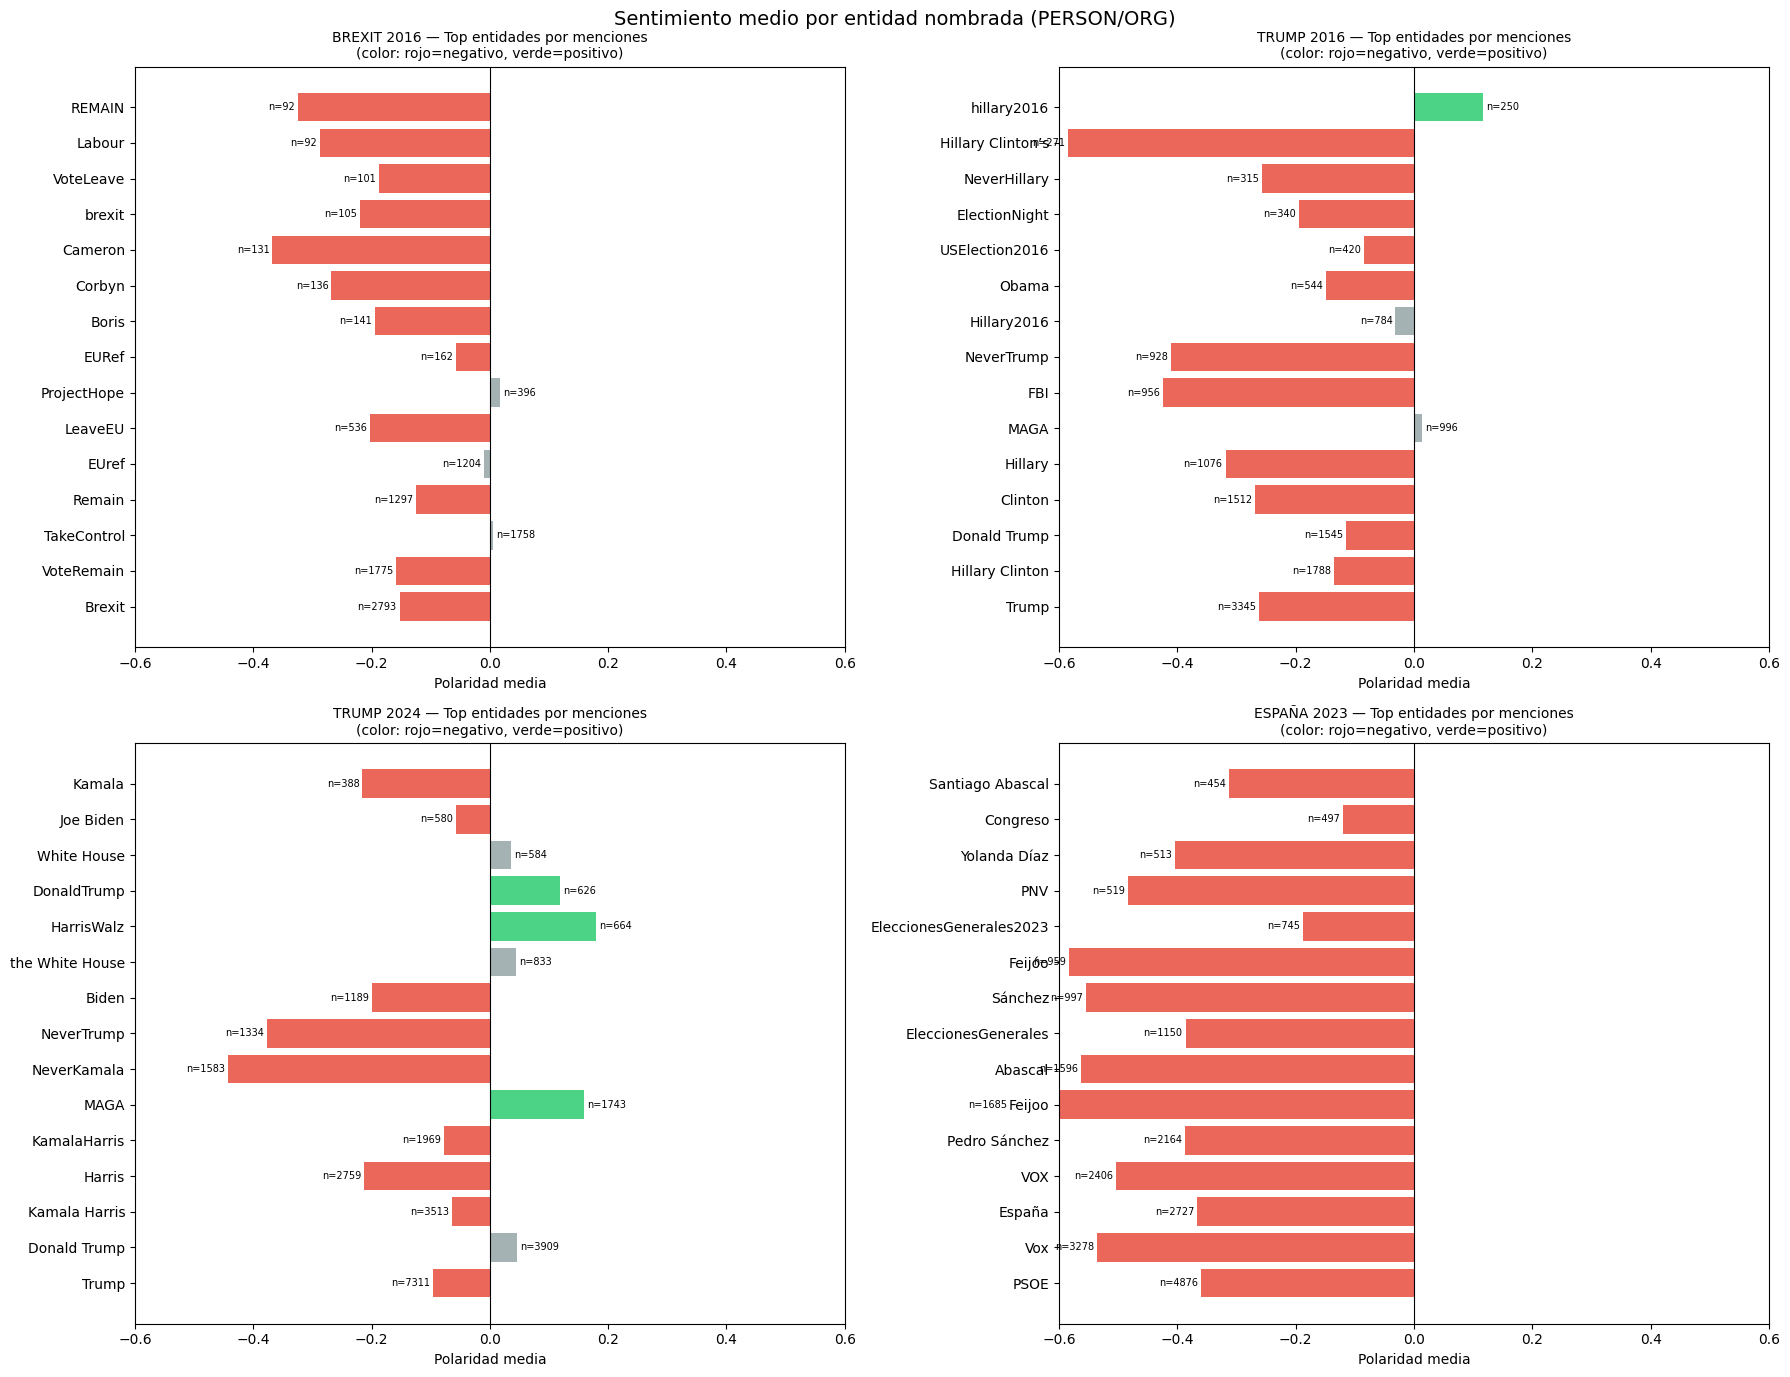

In [6]:
def entity_sentiment(df, pol_col='polarity', min_mentions=50):
    """Para cada entidad, devuelve polaridad media y nº menciones."""
    records = []
    for _, row in df.iterrows():
        for ent in row.get('entities', []):
            if len(ent) < 3: continue
            records.append({'entity': ent, 'polarity': row[pol_col]})
    df_ents = pd.DataFrame(records)
    if df_ents.empty:
        return pd.DataFrame()
    agg = df_ents.groupby('entity').agg(
        n=('polarity','count'),
        pol_mean=('polarity','mean'),
        pol_std=('polarity','std'),
    ).reset_index()
    return agg[agg['n'] >= min_mentions].sort_values('n', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, (campaign, df) in zip(axes, ner_results.items()):
    pol_col = 'polarity'
    if campaign == 'españa_2023':
        # Usar RoBERTuito para España
        df = df.merge(df_es_dual[['id','polarity_robertuito']], on='id', how='left')
        pol_col = 'polarity_robertuito'

    agg = entity_sentiment(df, pol_col=pol_col, min_mentions=30)
    if agg.empty:
        ax.set_title(f'{campaign} — sin entidades suficientes')
        continue

    top = agg.head(15)
    colors = ['#e74c3c' if p < -0.05 else '#2ecc71' if p > 0.05 else '#95a5a6'
              for p in top['pol_mean']]
    bars = ax.barh(top['entity'], top['pol_mean'], color=colors, alpha=0.85)
    ax.axvline(0, color='black', lw=0.8)
    for bar, n in zip(bars, top['n']):
        x = bar.get_width()
        ax.text(x + 0.005 if x >= 0 else x - 0.005, bar.get_y() + bar.get_height()/2,
                f'n={n}', va='center', ha='left' if x >= 0 else 'right', fontsize=7)
    ax.set_xlabel('Polaridad media')
    ax.set_title(f'{campaign.replace("_"," ").upper()} — Top entidades por menciones\n(color: rojo=negativo, verde=positivo)',
                 fontsize=10)
    ax.set_xlim(-0.6, 0.6)

plt.suptitle('Sentimiento medio por entidad nombrada (PERSON/ORG)', fontsize=14)
plt.tight_layout()
plt.savefig('figures/06_ner_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Multipartidismo España 2023

España 2023 es la única campaña multipartidista del corpus. Filtramos tweets por mención explícita de cada partido o su líder y comparamos el sentimiento (RoBERTuito) y la evolución temporal.

In [7]:
PARTIES = {
    'PP / Feijóo':  r'\b(PP|Partido Popular|Feij[oó]o|peperos?)\b',
    'PSOE / Sánchez': r'\b(PSOE|Partido Socialista|S[aá]nchez|socialistas?)\b',
    'Vox / Abascal': r'\b(Vox|Abascal|ultradere|voxeros?)\b',
    'Sumar / Díaz':  r'\b(Sumar|Yolanda D[ií]az|Unidas Podemos|Irene Montero)\b',
}

df_es = df_es_dual.copy()
df_es['date'] = pd.to_datetime(df_es['date'])

# Asignar partido (puede ser varios → tomamos primero)
for party, pattern in PARTIES.items():
    df_es[f'mention_{party}'] = df_es['text'].str.contains(pattern, case=False, regex=True, na=False)

# Resumen distribución
print('Menciones por partido:')
for party in PARTIES:
    n = df_es[f'mention_{party}'].sum()
    pct = n / len(df_es) * 100
    print(f'  {party}: {n:,} tweets ({pct:.1f}%)')

print()
print('Sentimiento RoBERTuito por partido:')
for party in PARTIES:
    sub = df_es[df_es[f'mention_{party}']]
    if len(sub) < 10:
        print(f'  {party}: insuficientes')
        continue
    dist = sub['sentiment_robertuito'].value_counts(normalize=True).mul(100).round(1)
    pol  = sub['polarity_robertuito'].mean()
    print(f'  {party} (n={len(sub):,}): neg={dist.get("negativo",0):.1f}% neu={dist.get("neutro",0):.1f}% pos={dist.get("positivo",0):.1f}% | pol={pol:.3f}')

Menciones por partido:
  PP / Feijóo: 11,007 tweets (30.3%)
  PSOE / Sánchez: 11,373 tweets (31.3%)
  Vox / Abascal: 9,564 tweets (26.3%)
  Sumar / Díaz: 7,102 tweets (19.5%)

Sentimiento RoBERTuito por partido:
  PP / Feijóo (n=11,007): neg=68.3% neu=29.2% pos=2.5% | pol=-0.538
  PSOE / Sánchez (n=11,373): neg=55.5% neu=39.1% pos=5.4% | pol=-0.403
  Vox / Abascal (n=9,564): neg=63.8% neu=31.7% pos=4.5% | pol=-0.492
  Sumar / Díaz (n=7,102): neg=44.6% neu=46.4% pos=9.0% | pol=-0.299


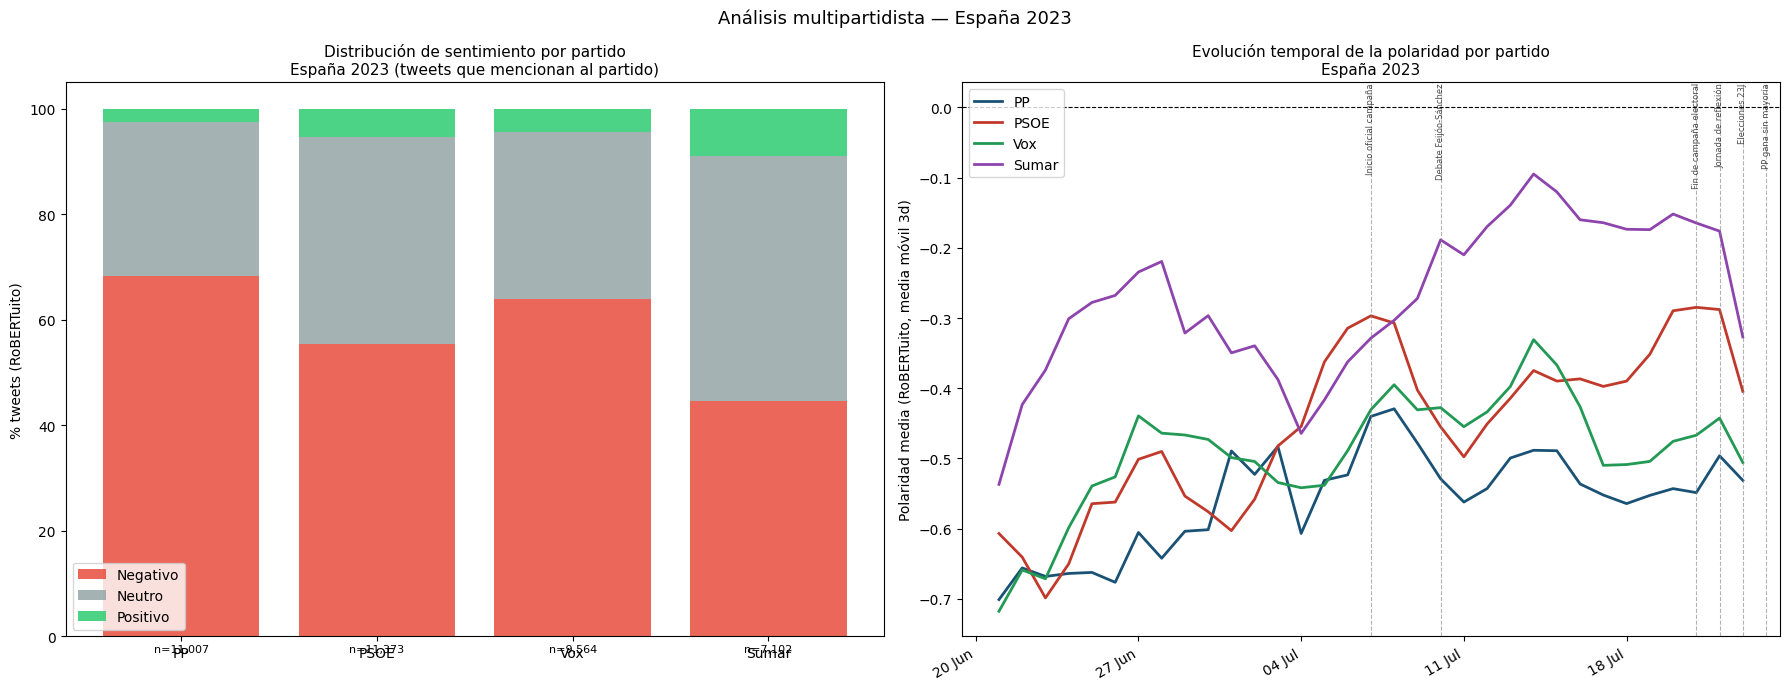

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Panel 1: distribución de sentimiento por partido ---
ax = axes[0]
party_data = {}
for party in PARTIES:
    sub = df_es[df_es[f'mention_{party}']]
    if len(sub) < 10: continue
    party_data[party] = {
        'negativo':  sub['sentiment_robertuito'].eq('negativo').mean()*100,
        'neutro':    sub['sentiment_robertuito'].eq('neutro').mean()*100,
        'positivo':  sub['sentiment_robertuito'].eq('positivo').mean()*100,
        'n': len(sub),
    }

labels  = list(party_data.keys())
x       = np.arange(len(labels))
neg_arr = [party_data[p]['negativo'] for p in labels]
neu_arr = [party_data[p]['neutro']   for p in labels]
pos_arr = [party_data[p]['positivo'] for p in labels]

b1 = ax.bar(x, neg_arr, label='Negativo', color='#e74c3c', alpha=0.85)
b2 = ax.bar(x, neu_arr, bottom=neg_arr, label='Neutro', color='#95a5a6', alpha=0.85)
b3 = ax.bar(x, pos_arr, bottom=[n+e for n,e in zip(neg_arr,neu_arr)], label='Positivo', color='#2ecc71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([p.split('/')[0].strip() for p in labels], fontsize=10)
ax.set_ylabel('% tweets (RoBERTuito)')
ax.set_title('Distribución de sentimiento por partido\nEspaña 2023 (tweets que mencionan al partido)', fontsize=11)
ax.legend()
for bar, p in zip(b1, labels):
    ax.text(bar.get_x() + bar.get_width()/2, -3, f'n={party_data[p]["n"]:,}',
            ha='center', fontsize=8)

# --- Panel 2: timeline de polaridad por partido ---
ax2 = axes[1]
party_colors = {'PP / Feijóo': '#1a5276', 'PSOE / Sánchez': '#c0392b',
                'Vox / Abascal': '#229954', 'Sumar / Díaz': '#8e44ad'}

for party in PARTIES:
    sub = df_es[df_es[f'mention_{party}']].copy()
    if len(sub) < 30: continue
    daily = sub.groupby('date')['polarity_robertuito'].mean().reset_index()
    daily['date'] = pd.to_datetime(daily['date'])
    daily['rolling'] = daily['polarity_robertuito'].rolling(3, center=True).mean()
    ax2.plot(daily['date'], daily['rolling'], label=party.split('/')[0].strip(),
             color=party_colors.get(party, 'grey'), lw=2)

ax2.axhline(0, color='black', lw=0.8, ls='--')
for event_date, label in KEY_EVENTS['españa_2023']:
    ed = pd.Timestamp(event_date)
    ax2.axvline(ed, color='grey', linestyle='--', lw=0.8, alpha=0.6)
    ax2.text(ed, ax2.get_ylim()[1] if ax2.get_ylim()[1] else 0.1,
             label.split('\n')[0], fontsize=6, rotation=90, ha='center', va='top', alpha=0.7)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.set_ylabel('Polaridad media (RoBERTuito, media móvil 3d)')
ax2.set_title('Evolución temporal de la polaridad por partido\nEspaña 2023', fontsize=11)
ax2.legend()

plt.suptitle('Análisis multipartidista — España 2023', fontsize=13)
plt.tight_layout()
plt.savefig('figures/06_multipartidismo.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Comparativa GPT-4o mini

Aplicamos GPT-4o mini como clasificador zero-shot sobre una muestra de 50 tweets por campaña (200 total) y comparamos los resultados con E0. **Requiere `OPENAI_API_KEY` en el entorno.**

API key cargada desde /content/openai_key.txt
GPT-4o mini → brexit_2016 (n=50)...
GPT-4o mini → trump_2016 (n=50)...
GPT-4o mini → trump_2024 (n=50)...
GPT-4o mini → españa_2023 (n=50)...

Acuerdo E0 vs GPT-4o mini:
campaign
brexit_2016    48.0
españa_2023    94.0
trump_2016     22.0
trump_2024     40.0

Acuerdo global: 51.0%


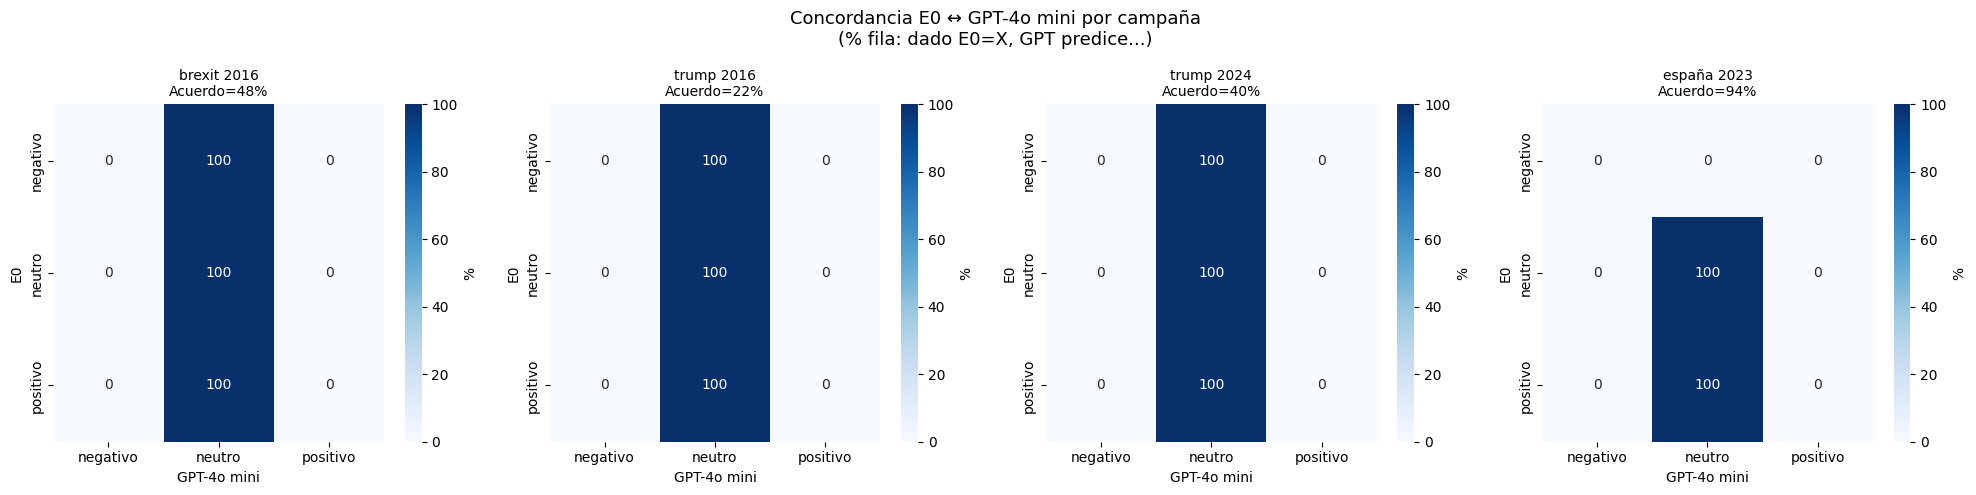

In [9]:
import openai, time

OPENAI_KEY = os.environ.get('OPENAI_API_KEY', '')

# Fallback: archivo .txt (formato "sk-..." o "OPENAI_API_KEY=sk-...")
if not OPENAI_KEY:
    for _path in ['/content/openai_key.txt', 'openai_key.txt',
                  '/Users/jimenamillamoreno/Desktop/TFM/TFM/scrapper/openai_key.txt']:
        if os.path.exists(_path):
            _raw = open(_path).read().strip()
            OPENAI_KEY = _raw.split('=')[-1].strip()
            print(f'API key cargada desde {_path}')
            break

if not OPENAI_KEY:
    print('OPENAI_API_KEY no configurada — celda omitida.')
else:
    client_oai = openai.OpenAI(api_key=OPENAI_KEY)
    SAMPLE_N   = 50
    GPT_MODEL  = 'gpt-4o-mini'

    SYSTEM_PROMPT = (
        'Eres un clasificador de sentimiento para tweets políticos. '
        'Clasifica el sentimiento del tweet como exactamente una de estas tres palabras: '
        'negativo, neutro, positivo. Responde SOLO con la palabra, sin explicación.'
    )

    gpt_records = []
    for campaign, df in dfs.items():
        print(f'GPT-4o mini → {campaign} (n={SAMPLE_N})...')
        sample = df.sample(SAMPLE_N, random_state=42)
        for _, row in sample.iterrows():
            try:
                resp = client_oai.chat.completions.create(
                    model=GPT_MODEL,
                    messages=[
                        {'role': 'system', 'content': SYSTEM_PROMPT},
                        {'role': 'user',   'content': str(row['text'])[:512]},
                    ],
                    max_tokens=5,
                    temperature=0,
                )
                gpt_label = resp.choices[0].message.content.strip().lower()
                if gpt_label not in ('negativo', 'neutro', 'positivo'):
                    gpt_label = 'neutro'
            except Exception as e:
                gpt_label = 'neutro'
            gpt_records.append({
                'campaign':   campaign,
                'id':         row['id'],
                'e0_label':   row['sentiment'],
                'gpt_label':  gpt_label,
                'text':       str(row['text'])[:200],
            })
            time.sleep(0.05)  # rate limit

    df_gpt = pd.DataFrame(gpt_records)

    # Acuerdo
    df_gpt['agree'] = df_gpt['e0_label'] == df_gpt['gpt_label']
    print('\nAcuerdo E0 vs GPT-4o mini:')
    print(df_gpt.groupby('campaign')['agree'].mean().mul(100).round(1).to_string())
    print(f'\nAcuerdo global: {df_gpt["agree"].mean()*100:.1f}%')

    # Matriz de confusión cruzada
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    order = ['negativo', 'neutro', 'positivo']
    for ax, campaign in zip(axes, CAMPAIGNS):
        sub = df_gpt[df_gpt['campaign'] == campaign]
        cm  = pd.crosstab(sub['e0_label'], sub['gpt_label'], normalize='index') * 100
        cm  = cm.reindex(index=order, columns=order, fill_value=0)
        sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', ax=ax, vmin=0, vmax=100,
                    cbar_kws={'label': '%'})
        ax.set_title(f'{campaign.replace("_"," ")}\nAcuerdo={sub["agree"].mean()*100:.0f}%', fontsize=10)
        ax.set_xlabel('GPT-4o mini'); ax.set_ylabel('E0')
    plt.suptitle('Concordancia E0 ↔ GPT-4o mini por campaña\n(% fila: dado E0=X, GPT predice...)', fontsize=13)
    plt.tight_layout()
    plt.savefig('figures/06_gpt_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Correlación sentimiento × resultado electoral

¿El sentimiento en Twitter predice (o refleja) el resultado electoral? Comparamos la distribución de sentimiento en la semana previa a las elecciones con el resultado final.

   campaign ganador  voto_%  pol_semana_previa  pct_pos_semana  pct_neg_semana  n_tweets_semana
brexit_2016   Leave    51.9            -0.0614            14.6            25.5             2274
 trump_2016   Trump    46.1            -0.0452            23.6            32.4             1889
 trump_2024   Trump    49.8            -0.0891            25.7            37.7             1893
españa_2023      PP    33.0            -0.2607             9.1            40.4            10663


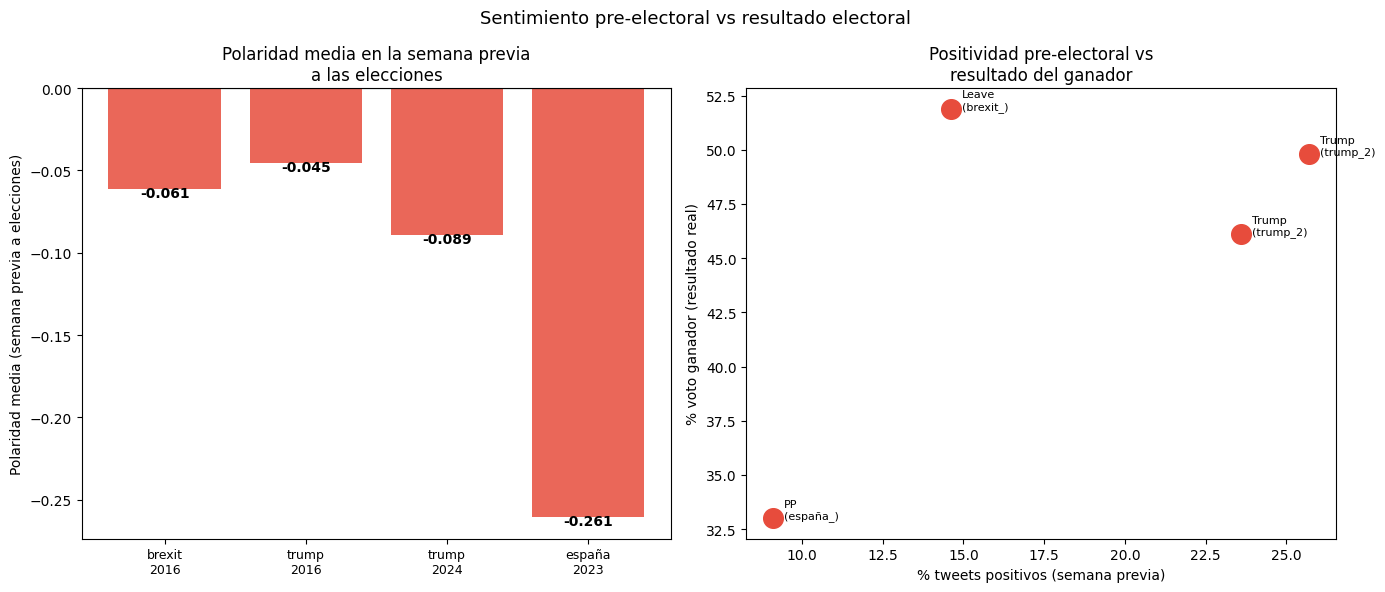

In [10]:
# Resultados electorales reales
ELECTORAL_RESULTS = {
    'brexit_2016':  {'ganador': 'Leave',   'resultado': 51.9,  'perdedor': 'Remain',  'resultado_2': 48.1},
    'trump_2016':   {'ganador': 'Trump',   'resultado': 46.1,  'perdedor': 'Clinton', 'resultado_2': 48.2},
    'trump_2024':   {'ganador': 'Trump',   'resultado': 49.8,  'perdedor': 'Harris',  'resultado_2': 48.3},
    'españa_2023':  {'ganador': 'PP',      'resultado': 33.0,  'perdedor': 'PSOE',    'resultado_2': 31.7},
}

# Ventana: última semana antes de elecciones
ELECTION_DAY = {
    'brexit_2016': '2016-06-23',
    'trump_2016':  '2016-11-08',
    'trump_2024':  '2024-11-05',
    'españa_2023': '2023-07-23',
}

results = []
for campaign, df in dfs.items():
    pol_col = 'polarity'
    df_use  = df.copy()
    if campaign == 'españa_2023':
        df_use  = df_es_dual.copy()
        pol_col = 'polarity_robertuito'
    df_use['date'] = pd.to_datetime(df_use['date'])

    eday  = pd.Timestamp(ELECTION_DAY[campaign])
    week  = df_use[(df_use['date'] >= eday - pd.Timedelta(days=7)) & (df_use['date'] < eday)]
    pol_week = week[pol_col].mean()
    pct_pos  = (week['sentiment'] == 'positivo').mean() * 100 if campaign != 'españa_2023' else \
               (week['sentiment_robertuito'] == 'positivo').mean() * 100
    pct_neg  = (week['sentiment'] == 'negativo').mean() * 100 if campaign != 'españa_2023' else \
               (week['sentiment_robertuito'] == 'negativo').mean() * 100

    er = ELECTORAL_RESULTS[campaign]
    results.append({
        'campaign':  campaign,
        'ganador':   er['ganador'],
        'voto_%':    er['resultado'],
        'pol_semana_previa': round(pol_week, 4),
        'pct_pos_semana':    round(pct_pos, 1),
        'pct_neg_semana':    round(pct_neg, 1),
        'n_tweets_semana':   len(week),
    })

df_elec = pd.DataFrame(results)
print(df_elec.to_string(index=False))

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: polaridad semana previa
ax = axes[0]
camp_labels = [r['campaign'].replace('_','\n') for r in results]
pols = [r['pol_semana_previa'] for r in results]
cols = ['#2ecc71' if p > 0 else '#e74c3c' for p in pols]
bars = ax.bar(range(len(results)), pols, color=cols, alpha=0.85)
for bar, r in zip(bars, results):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002 if bar.get_height() >= 0 else bar.get_height() - 0.005,
            f'{bar.get_height():+.3f}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(results)))
ax.set_xticklabels(camp_labels, fontsize=9)
ax.set_ylabel('Polaridad media (semana previa a elecciones)')
ax.set_title('Polaridad media en la semana previa\na las elecciones')

# Panel 2: ganador vs sentimiento
ax2 = axes[1]
for i, r in enumerate(results):
    color = '#2ecc71' if r['pol_semana_previa'] > 0 else '#e74c3c'
    ax2.scatter(r['pct_pos_semana'], r['voto_%'], s=200, color=color, zorder=5)
    ax2.annotate(f"{r['ganador']}\n({r['campaign'][:7]})",
                 (r['pct_pos_semana'], r['voto_%']),
                 textcoords='offset points', xytext=(8, 0), fontsize=8)
ax2.set_xlabel('% tweets positivos (semana previa)')
ax2.set_ylabel('% voto ganador (resultado real)')
ax2.set_title('Positividad pre-electoral vs\nresultado del ganador')

plt.suptitle('Sentimiento pre-electoral vs resultado electoral', fontsize=13)
plt.tight_layout()
plt.savefig('figures/06_electoral_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Conclusiones integradas

Síntesis comparativa de los hallazgos principales a través de las cuatro campañas.

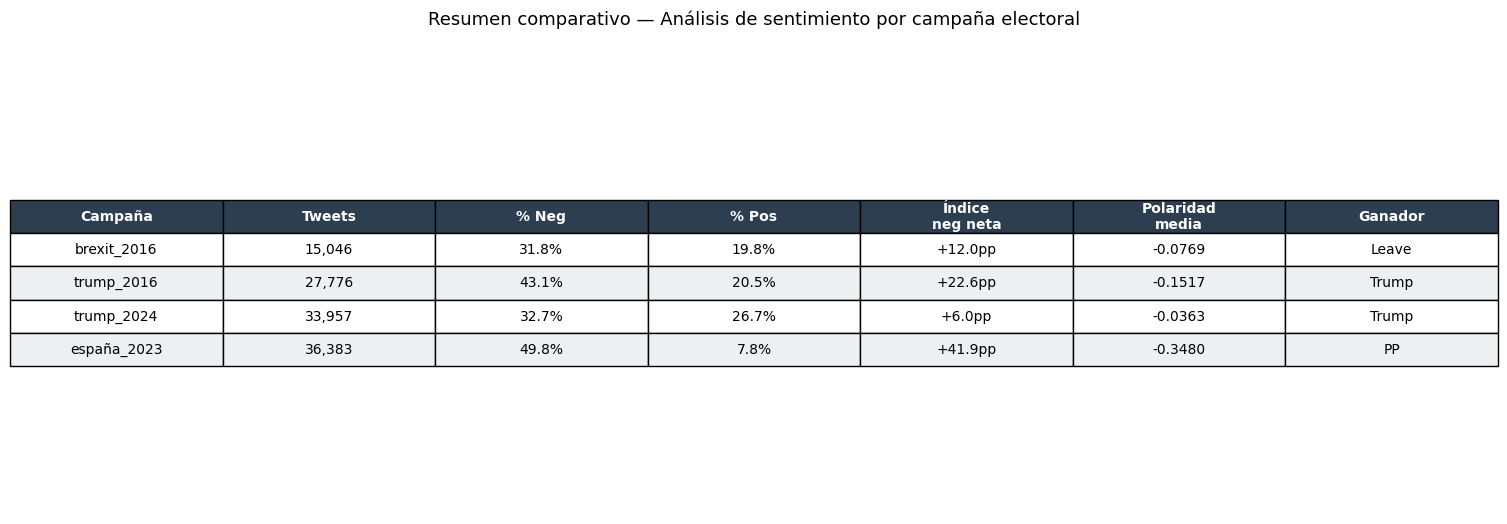


Tabla resumen:
    Campaña Tweets % Neg % Pos Índice\nneg neta Polaridad\nmedia Ganador
brexit_2016 15,046 31.8% 19.8%          +12.0pp          -0.0769   Leave
 trump_2016 27,776 43.1% 20.5%          +22.6pp          -0.1517   Trump
 trump_2024 33,957 32.7% 26.7%           +6.0pp          -0.0363   Trump
españa_2023 36,383 49.8%  7.8%          +41.9pp          -0.3480      PP


In [11]:
# Tabla resumen comparativo
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('off')

rows = []
for campaign, df in dfs.items():
    pol_col = 'polarity'
    df_use  = df_es_dual.copy() if campaign == 'españa_2023' else df.copy()
    pol_col = 'polarity_robertuito' if campaign == 'españa_2023' else 'polarity'
    df_use['date'] = pd.to_datetime(df_use['date'])
    sent_col = 'sentiment_robertuito' if campaign == 'españa_2023' else 'sentiment'

    pol_global = df_use[pol_col].mean()
    pct_neg    = df_use[sent_col].eq('negativo').mean() * 100
    pct_pos    = df_use[sent_col].eq('positivo').mean() * 100
    pol_idx    = pct_neg - pct_pos

    rows.append([
        campaign,
        f'{len(df_use):,}',
        f'{pct_neg:.1f}%',
        f'{pct_pos:.1f}%',
        f'{pol_idx:+.1f}pp',
        f'{pol_global:+.4f}',
        ELECTORAL_RESULTS[campaign]['ganador'],
    ])

cols = ['Campaña', 'Tweets', '% Neg', '% Pos', 'Índice\nneg neta', 'Polaridad\nmedia', 'Ganador']
table = ax.table(cellText=rows, colLabels=cols, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#ecf0f1')

plt.title('Resumen comparativo — Análisis de sentimiento por campaña electoral', fontsize=13, pad=20)
plt.savefig('figures/06_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTabla resumen:')
print(pd.DataFrame(rows, columns=cols).to_string(index=False))

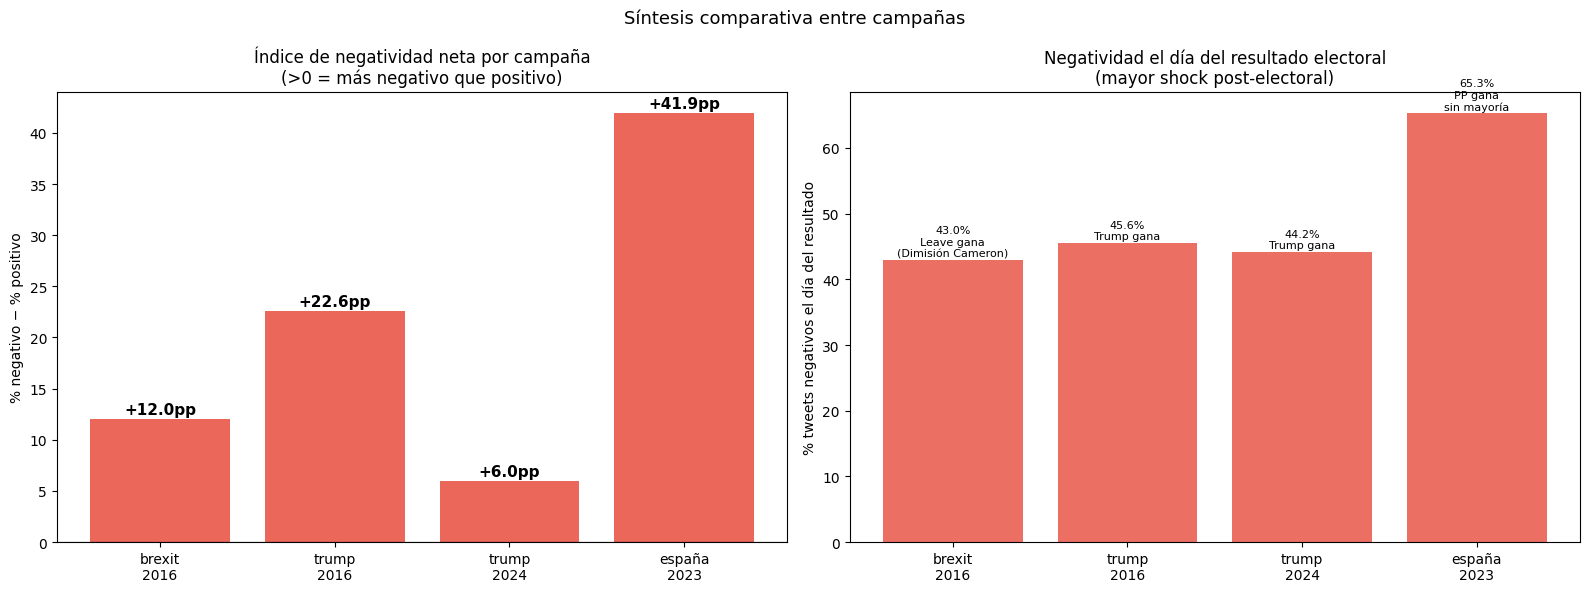

In [12]:
# Gráfico radar: comparativa multidimensional entre campañas
import matplotlib.patches as mpatches
from matplotlib.path import Path

# Dimensiones normalizadas 0-1
# negatividad, volumen, virality_neg, shock_count, polaridad_abs
camp_labels_short = ['brexit\n2016', 'trump\n2016', 'trump\n2024', 'españa\n2023']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: índice de negatividad neta por campaña
ax = axes[0]
neg_idx = []
for campaign, df in dfs.items():
    sent_col = 'sentiment_robertuito' if campaign == 'españa_2023' else 'sentiment'
    df_use   = df_es_dual if campaign == 'españa_2023' else df
    neg = df_use[sent_col].eq('negativo').mean() * 100
    pos = df_use[sent_col].eq('positivo').mean() * 100
    neg_idx.append(neg - pos)

cols_bar = ['#e74c3c' if v > 0 else '#2ecc71' for v in neg_idx]
bars = ax.bar(range(4), neg_idx, color=cols_bar, alpha=0.85)
for bar, v in zip(bars, neg_idx):
    ax.text(bar.get_x() + bar.get_width()/2,
            v + 0.5 if v >= 0 else v - 1.5,
            f'{v:+.1f}pp', ha='center', fontsize=11, fontweight='bold')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(4)); ax.set_xticklabels(camp_labels_short)
ax.set_ylabel('% negativo − % positivo')
ax.set_title('Índice de negatividad neta por campaña\n(>0 = más negativo que positivo)')

# Panel 2: evolución del shock más importante por campaña
ax2 = axes[1]
shock_info = {
    'brexit_2016': ('2016-06-24', 'Leave gana\n(Dimisión Cameron)', 43.0),
    'trump_2016':  ('2016-11-09', 'Trump gana', 45.6),
    'trump_2024':  ('2024-11-06', 'Trump gana', 44.2),
    'españa_2023': ('2023-07-24', 'PP gana\nsin mayoría', 65.3),
}

for i, (campaign, (date, label, pct_neg)) in enumerate(shock_info.items()):
    ax2.bar(i, pct_neg, color='#e74c3c', alpha=0.8)
    ax2.text(i, pct_neg + 0.5, f'{pct_neg:.1f}%\n{label}', ha='center', fontsize=8)

ax2.set_xticks(range(4)); ax2.set_xticklabels(camp_labels_short)
ax2.set_ylabel('% tweets negativos el día del resultado')
ax2.set_title('Negatividad el día del resultado electoral\n(mayor shock post-electoral)')

plt.suptitle('Síntesis comparativa entre campañas', fontsize=13)
plt.tight_layout()
plt.savefig('figures/06_comparative_synthesis.png', dpi=150, bbox_inches='tight')
plt.show()